# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

In [3]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datos_crudos = pd.read_csv('../src/data/raw/housing/housing.csv')
print(datos_crudos.head())
type(datos_crudos) # si es un data set

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


pandas.core.frame.DataFrame

# Análisis exploratorio de datos

In [4]:
datos_crudos.info() # para ver el tipo de datos y si hay valores nulos


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# Crear resumen de valores nulos
resumen_nulos = pd.DataFrame({
    'valores_nulos': datos_crudos.isnull().sum(),
    'porcentaje_nulos': (datos_crudos.isnull().sum() / len(datos_crudos)) * 100
})

# Redondear porcentaje a 2 decimales
resumen_nulos['porcentaje_nulos'] = resumen_nulos['porcentaje_nulos'].round(4)

# Ordenar de mayor a menor
resumen_nulos = resumen_nulos.sort_values(by='porcentaje_nulos', ascending=False)

# Mostrar solo columnas con nulos
resumen_nulos_filtrado = resumen_nulos[resumen_nulos['valores_nulos'] > 0]

resumen_nulos, resumen_nulos_filtrado

(                    valores_nulos  porcentaje_nulos
 total_bedrooms                207            1.0029
 longitude                       0            0.0000
 latitude                        0            0.0000
 housing_median_age              0            0.0000
 total_rooms                     0            0.0000
 population                      0            0.0000
 households                      0            0.0000
 median_income                   0            0.0000
 median_house_value              0            0.0000
 ocean_proximity                 0            0.0000,
                 valores_nulos  porcentaje_nulos
 total_bedrooms            207            1.0029)

### Conclusión

Se identificó que la variable `total_bedrooms` presenta aproximadamente un 1% de valores faltantes en el dataset.

Dado que la proporción de datos faltantes es baja, se considera que su impacto en el análisis global es limitado.

Adicionalmente, en el análisis exploratorio no se evidenciaron patrones o relaciones significativas que indiquen que la ausencia de estos datos esté sesgando el comportamiento del dataset.

Por lo tanto, se optó por imputar los valores faltantes utilizando la mediana de la variable, debido a su robustez frente a valores atípicos y su capacidad de representar adecuadamente la tendencia central de los datos.

Esta decisión permite conservar la integridad del dataset sin introducir sesgos significativos en el análisis posterior.

In [6]:
mediana_bedrooms = datos_crudos['total_bedrooms'].median()
datos_crudos['total_bedrooms'] = datos_crudos['total_bedrooms'].fillna(mediana_bedrooms)
datos_crudos['total_bedrooms'].isnull().sum()
datos_crudos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
# Selecciona únicamente las columnas numéricas del DataFrame
columnas_numericas = datos_crudos.select_dtypes(include=['float64', 'int64']).columns

# Calcula el valor mínimo de cada columna numérica
valores_minimos = datos_crudos[columnas_numericas].min()

# Calcula el valor máximo de cada columna numérica
valores_maximos = datos_crudos[columnas_numericas].max()

# Construye un DataFrame resumen con mínimos y máximos
resumen_rangos = pd.DataFrame({
    'valor_minimo': valores_minimos,
    'valor_maximo': valores_maximos
})

# Muestra la tabla resumen
resumen_rangos

,valor_minimo,valor_maximo
longitude,-124.3500,-114.3100
latitude,32.5400,41.9500
housing_median_age,1.0000,52.0000
total_rooms,2.0000,39320.0000
total_bedrooms,1.0000,6445.0000
population,3.0000,35682.0000
households,1.0000,6082.0000
median_income,0.4999,15.0001
median_house_value,14999.0000,500001.0000


In [8]:
# Lista de columnas que deberían contener únicamente valores enteros
columnas_enteras_esperadas = [
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households'
]

# Crea un diccionario vacío para guardar resultados de inconsistencia
inconsistencias_decimales = {}

# Recorre cada columna que debería ser entera
for columna in columnas_enteras_esperadas:
    
    # Filtra filas donde el valor no es nulo y además tiene parte decimal distinta de cero
    filas_inconsistentes = datos_crudos[
        datos_crudos[columna].notna() & (datos_crudos[columna] % 1 != 0)
    ]
    
    # Guarda en el diccionario solo las filas que incumplen la regla
    inconsistencias_decimales[columna] = filas_inconsistentes

# Muestra cuántas inconsistencias tiene cada columna
for columna, tabla in inconsistencias_decimales.items():
    print(f"{columna}: {len(tabla)} filas con decimales no esperados")

housing_median_age: 0 filas con decimales no esperados
total_rooms: 0 filas con decimales no esperados
total_bedrooms: 0 filas con decimales no esperados
population: 0 filas con decimales no esperados
households: 0 filas con decimales no esperados


In [9]:
# Filtra filas donde total_bedrooms es mayor que total_rooms
regla_rooms_bedrooms = datos_crudos[
    datos_crudos['total_bedrooms'].notna() &
    (datos_crudos['total_bedrooms'] > datos_crudos['total_rooms'])
]

# Muestra cuántas filas violan la regla
print("Filas con total_bedrooms > total_rooms:", len(regla_rooms_bedrooms))

# Muestra las filas inconsistentes
regla_rooms_bedrooms

Filas con total_bedrooms > total_rooms: 5


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1009,-120.85,37.78,25.0,421.0,435.0,303.0,106.0,2.2679,71300.0,INLAND
1984,-119.11,35.42,52.0,154.0,435.0,37.0,16.0,10.0263,200000.0,INLAND
3651,-122.23,38.17,45.0,350.0,435.0,225.0,72.0,1.8942,216700.0,NEAR BAY
7018,-117.28,34.09,44.0,376.0,435.0,273.0,107.0,2.2917,90800.0,INLAND
9827,-121.85,36.61,38.0,238.0,435.0,191.0,67.0,1.3897,125000.0,<1H OCEAN


In [10]:
datos_crudos[
    (datos_crudos['total_bedrooms'] > datos_crudos['total_rooms'])
]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1009,-120.85,37.78,25.0,421.0,435.0,303.0,106.0,2.2679,71300.0,INLAND
1984,-119.11,35.42,52.0,154.0,435.0,37.0,16.0,10.0263,200000.0,INLAND
3651,-122.23,38.17,45.0,350.0,435.0,225.0,72.0,1.8942,216700.0,NEAR BAY
7018,-117.28,34.09,44.0,376.0,435.0,273.0,107.0,2.2917,90800.0,INLAND
9827,-121.85,36.61,38.0,238.0,435.0,191.0,67.0,1.3897,125000.0,<1H OCEAN


In [12]:
# Lista de columnas que no deberían contener valores negativos
columnas_no_negativas = ['total_rooms', 'total_bedrooms', 'population', 'households']

# Recorre cada columna y busca valores negativos
for columna in columnas_no_negativas:
    
    # Filtra filas con valores negativos
    negativos = datos_crudos[datos_crudos[columna].notna() & (datos_crudos[columna] < 0)]
    
    # Imprime la cantidad de filas problemáticas
    print(f"{columna}: {len(negativos)} filas con valores negativos")

total_rooms: 0 filas con valores negativos
total_bedrooms: 0 filas con valores negativos
population: 0 filas con valores negativos
households: 0 filas con valores negativos


In [13]:
# Filtra filas con latitudes fuera del rango geográfico válido
latitudes_invalidas = datos_crudos[
    (datos_crudos['latitude'] < -90) | (datos_crudos['latitude'] > 90)
]

# Filtra filas con longitudes fuera del rango geográfico válido
longitudes_invalidas = datos_crudos[
    (datos_crudos['longitude'] < -180) | (datos_crudos['longitude'] > 180)
]

# Imprime cantidades detectadas
print("Latitudes inválidas:", len(latitudes_invalidas))
print("Longitudes inválidas:", len(longitudes_invalidas))

Latitudes inválidas: 0
Longitudes inválidas: 0


In [14]:
# Cuenta cuántas veces aparece cada categoría
datos_crudos['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9135
INLAND        6548
NEAR OCEAN    2658
NEAR BAY      2289
ISLAND           5
Name: count, dtype: int64

In [ ]:
# Filtra el DataFrame y muestra solo las filas donde ocean_proximity es 'ISLAND'
filas_island = datos_crudos[datos_crudos['ocean_proximity'] == 'ISLAND']
print(filas_island)

# Revisar esto para el tratamiento de los datos

In [16]:
# Filtrar filas donde total_bedrooms es nulo
filas_nulas = datos_crudos[datos_crudos['total_bedrooms'].isnull()]
filas_nulas


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [18]:
# Lista de columnas que conceptualmente deberían tener valores enteros
columnas_enteras_esperadas = [
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households'
]

# Diccionario donde guardaremos las filas inconsistentes por cada columna
inconsistencias_decimales = {}

# Recorre cada columna de la lista
for columna in columnas_enteras_esperadas:
    
    # Filtra las filas donde el valor no es nulo
    # y además tiene una parte decimal distinta de cero
    filas_inconsistentes = datos_crudos[
        datos_crudos[columna].notna() & (datos_crudos[columna] % 1 != 0)
    ]
    
    # Guarda esas filas en el diccionario usando el nombre de la columna como clave
    inconsistencias_decimales[columna] = filas_inconsistentes

# Recorre el diccionario para mostrar cuántas inconsistencias hubo por columna
for columna, tabla in inconsistencias_decimales.items():
    print(f"{columna}: {len(tabla)} filas con decimales no esperados")

housing_median_age: 0 filas con decimales no esperados
total_rooms: 0 filas con decimales no esperados
total_bedrooms: 0 filas con decimales no esperados
population: 0 filas con decimales no esperados
households: 0 filas con decimales no esperados


### Observación del Dataset

El dataset contiene 10 variables, de las cuales:

- 9 son de tipo numérico (`float64`)
- 1 es categórica (`object`): `ocean_proximity`

Se identifica la presencia de valores faltantes en la variable:

- `total_bedrooms`: 20433 valores no nulos de un total de 20640

Esto implica:

- **207 valores faltantes**
- Representa aproximadamente un **1.00% del total de datos**

El resto de variables no presenta valores nulos.

3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.

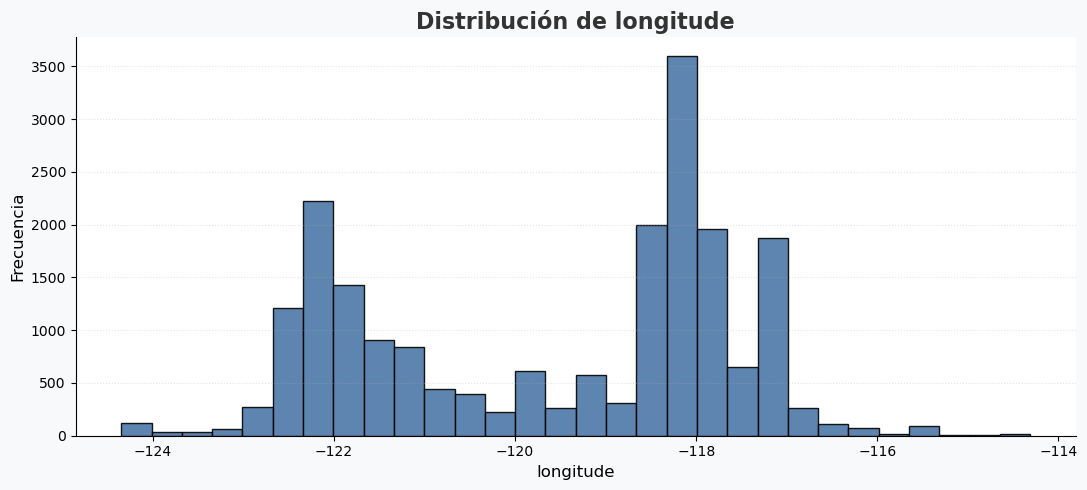

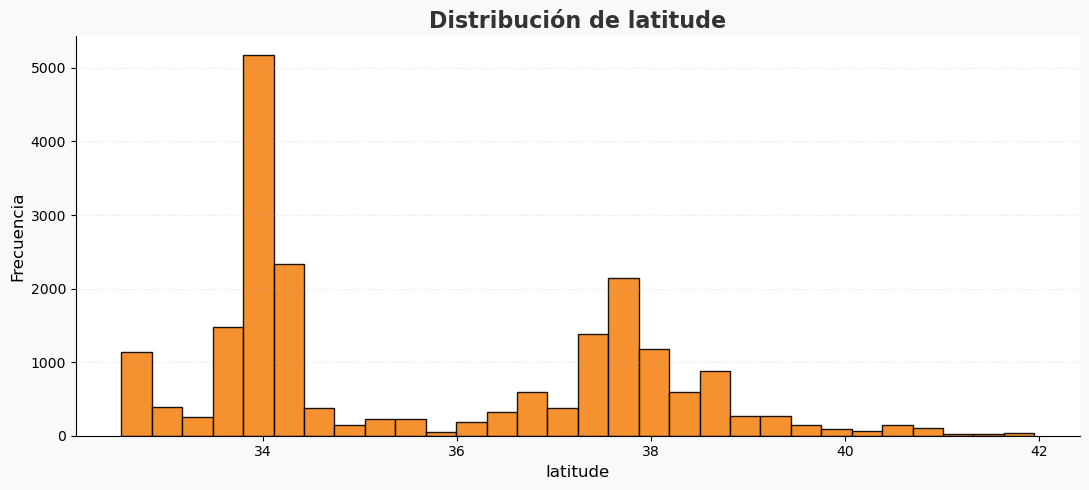

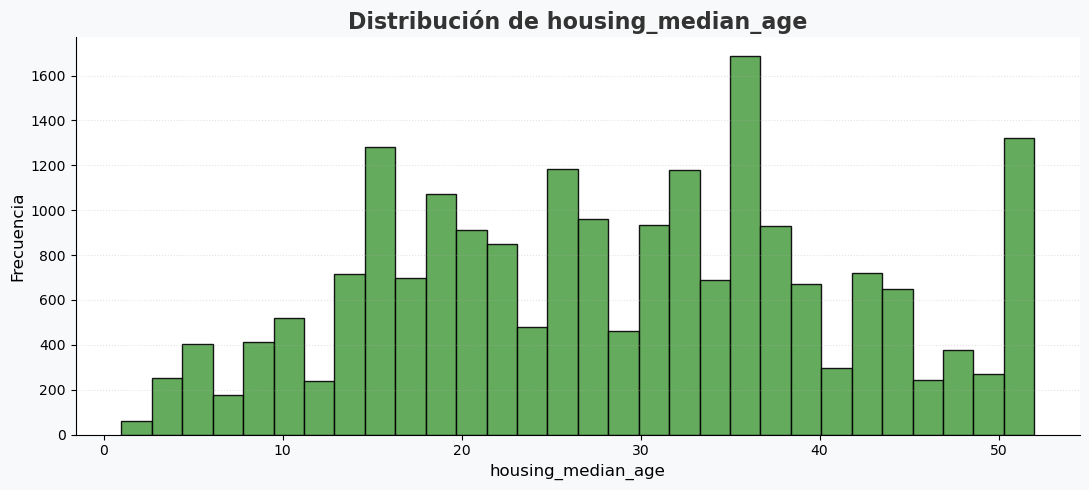

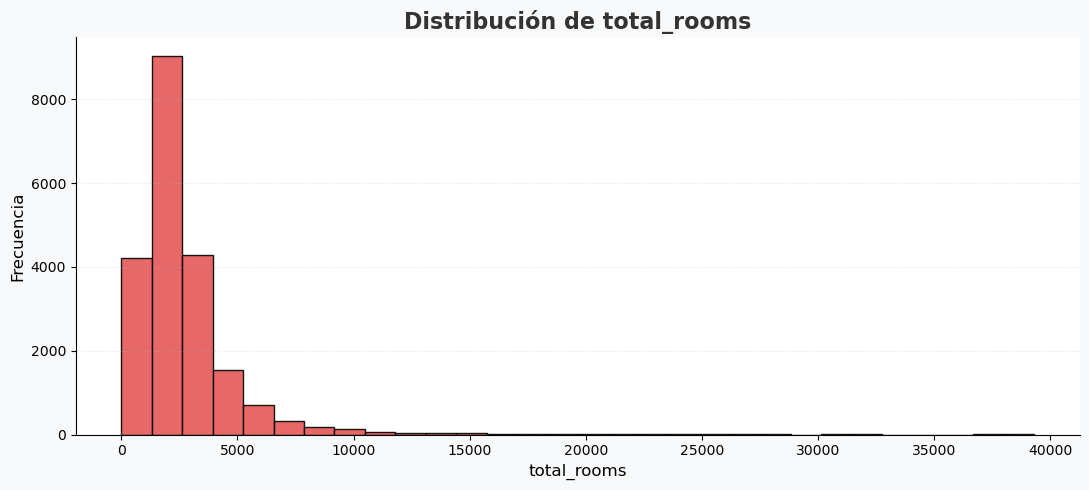

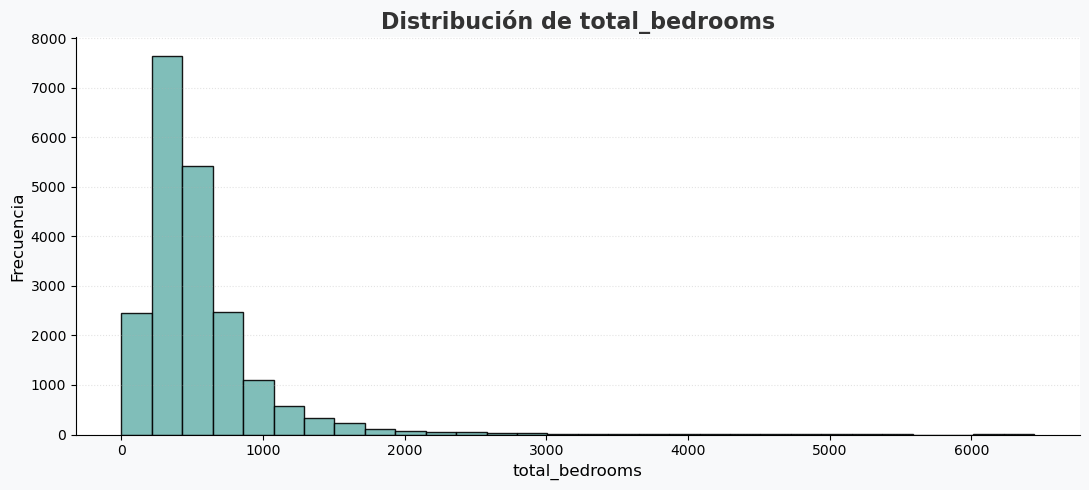

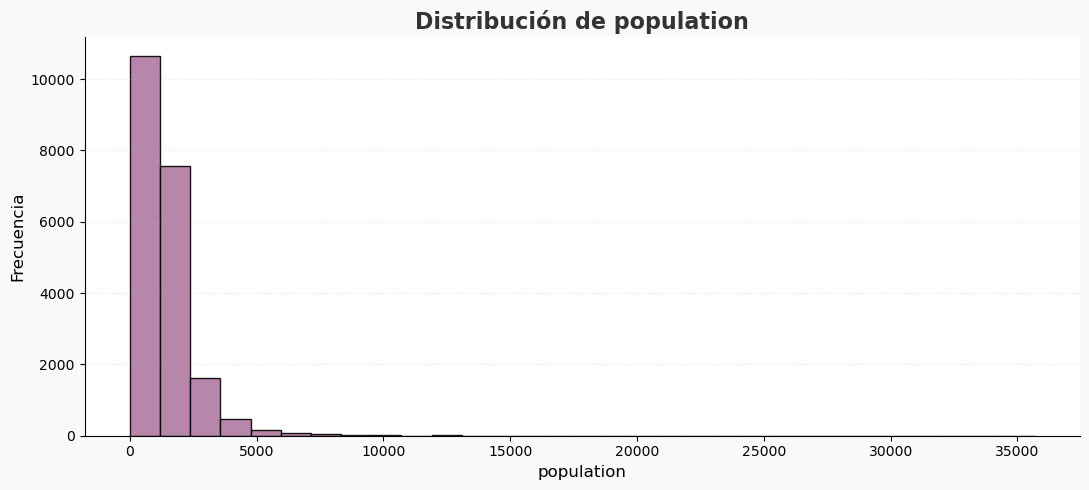

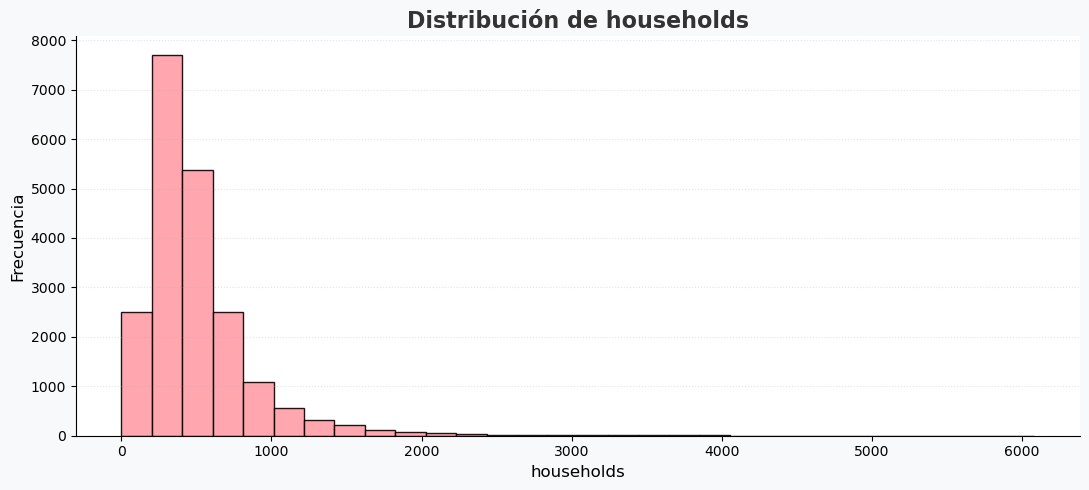

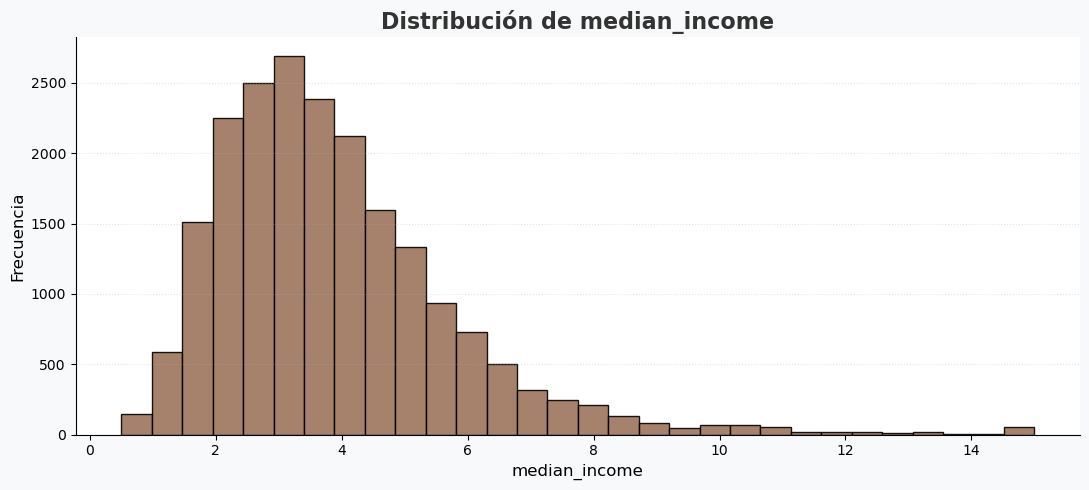

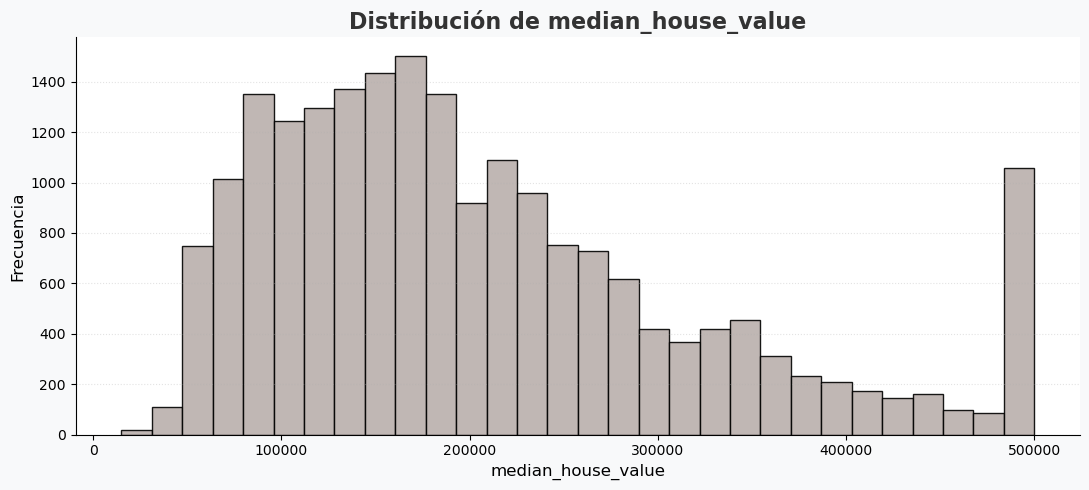

In [20]:
# Importa matplotlib para visualización
import matplotlib.pyplot as plt

# Lista de variables numéricas originales
columnas_originales = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
    'median_house_value'
]

# Lista de colores para ir alternando en los gráficos
paleta_colores = [
    '#4C78A8', '#F58518', '#54A24B',
    '#E45756', '#72B7B2', '#B279A2',
    '#FF9DA6', '#9D755D', '#BAB0AC'
]

# Recorre cada variable junto con un color
for columna, color in zip(columnas_originales, paleta_colores):
    
    # Crea una nueva figura individual
    plt.figure(figsize=(11, 5))
    
    # Cambia el color de fondo de la figura completa
    plt.gcf().patch.set_facecolor('#f8f9fa')
    
    # Cambia el color de fondo del área interna del gráfico
    plt.gca().set_facecolor('#ffffff')
    
    # Genera el histograma
    plt.hist(
        datos_crudos[columna].dropna(),
        bins=30,
        color=color,
        edgecolor='black',
        linewidth=1.0,
        alpha=0.9
    )
    
    # Agrega título llamativo
    plt.title(f'Distribución de {columna}', fontsize=16, fontweight='bold', color='#333333')
    
    # Etiqueta del eje X
    plt.xlabel(columna, fontsize=12)
    
    # Etiqueta del eje Y
    plt.ylabel('Frecuencia', fontsize=12)
    
    # Agrega cuadrícula tenue
    plt.grid(axis='y', linestyle=':', alpha=0.35)
    
    # Quita un poco de ruido visual en los bordes superiores y derechos
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    # Ajusta márgenes
    plt.tight_layout()
    
    # Muestra el gráfico
    plt.show()

4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.

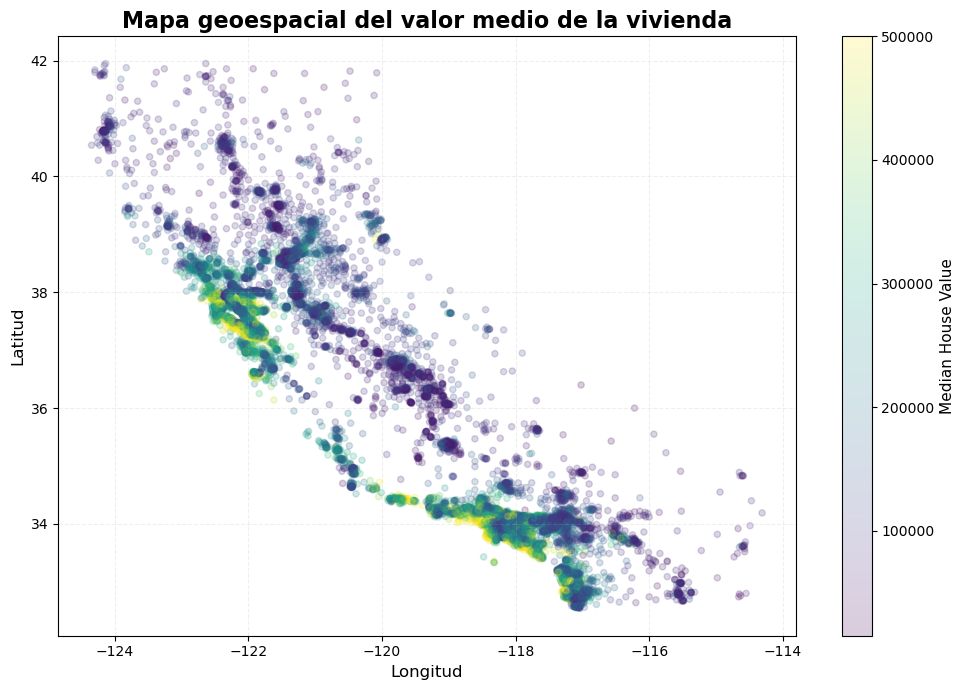

In [21]:
# Crea la figura
plt.figure(figsize=(10, 7))

# Genera el scatter plot
scatter = plt.scatter(
    datos_crudos['longitude'],
    datos_crudos['latitude'],
    alpha=0.2,
    c=datos_crudos['median_house_value'],
    cmap='viridis',
    s=20
)

# Agrega título
plt.title('Mapa geoespacial del valor medio de la vivienda', fontsize=16, fontweight='bold')

# Etiquetas de ejes
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Barra de color
cbar = plt.colorbar(scatter)
cbar.set_label('Median House Value', fontsize=11)

# Cuadrícula tenue
plt.grid(alpha=0.2, linestyle='--')

# Ajuste final
plt.tight_layout()

# Mostrar gráfico
plt.show()